<a href="https://colab.research.google.com/github/valeriachernaya/python-ai-Valeria-Chernaya/blob/main/notebooks/viz2_tripartite_graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔬 Исследовательское обоснование: граф экосистем

## Выбор layout алгоритма

Использован **Kamada-Kawai layout** вместо spring_layout по следующим причинам:
- Более стабильный результат при одинаковых входных данных
- Лучше отражает силу связей между вершинами
- Не требует подбора параметров (итераций, k-фактора)

## Визуальное кодирование

### Размеры вершин
- **Страны**: число производителей (от 1 до 15) — логично: чем больше брендов базируется в стране, тем крупнее узел
- **Производители**: число моделей (от 43 до 335) — Samsung и Xiaomi доминируют
- **ОС**: число производителей (от 2 до 13) — Android лидирует

### Толщина рёбер
Используется логарифмическая шкала `np.log1p(weight) * factor`, потому что:
- Линейная шкала сделала бы рёбра слишком толстыми
- Логарифм показывает относительные различия между связями

### Цветовое кодирование
- **Страны**: национальные цвета флага или ассоциативные цвета
- **ОС**: фирменные цвета платформ (Android — зелёный, Windows — оранжевый, iOS — серый)
- **Производители**: двухцветные пироги (страна слева, ОС справа)

## Интерпретация результатов

### Ключевые паттерны
1. **Android** находится в центре графа — 13 производителей, 1819 моделей
2. **iOS** изолирована на периферии — только Apple, 69 моделей
3. **Китай** формирует плотный кластер (Xiaomi, Huawei, OnePlus)
4. **Nokia** демонстрирует переход от Symbian к Windows Phone

### Неожиданные находки
- **Google** уникален: работает с Android (основной) и Fuchsia (экспериментальная)
- **Samsung** и **Xiaomi** почти монопольно привязаны к Android
- **HMD Global** (владелец бренда Nokia) продолжает выпускать Android-смартфоны

## Технические решения

Пироги для производителей реализованы через:
- Левую половину (страна) — сплошной цвет
- Правую половину (ОС) — сектора пропорционально долям
- Радиус = логарифм от числа моделей для масштабирования

Альтернативные подходы (полноценные круговые диаграммы) были отвергнуты из-за:
- Перегруженности визуализации
- Трудности восприятия маленьких секторов
- Лучшей читаемости двухполовинной структуры

In [2]:
# ===================================================
# ЯЧЕЙКА 1: Подготовка данных для графа
# ===================================================

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Wedge
from collections import defaultdict
import os

# Загружаем данные, если df_smartphones не существует
try:
    # Проверяем, существует ли уже df_smartphones
    if 'df_smartphones' not in globals():
        print("📂 Загружаем данные...")

        # Клонируем репозиторий если нужно
        repo_path = "/content/python-ai-Valeria-Chernaya"
        if not os.path.exists(repo_path):
            !git clone https://github.com/valeriachernaya/python-ai-Valeria-Chernaya.git
            os.chdir(repo_path)
        else:
            os.chdir(repo_path)
            print("✅ Репозиторий уже существует")

        # Читаем CSV
        df_smartphones = pd.read_csv("data/smartphones.csv")

        # Очищаем данные
        if "smartphoneLabel" in df_smartphones.columns:
            df_smartphones = df_smartphones.rename(columns={
                "smartphone": "URL",
                "smartphoneLabel": "smartphone",
                "countryLabel": "country",
                "osLabel": "os",
                "manufacturerLabel": "manufacturer",
            })

        # Преобразуем дату
        df_smartphones["releaseDate"] = pd.to_datetime(df_smartphones["releaseDate"], errors="coerce")

        # Группируем ОС
        top9 = df_smartphones['os'].value_counts().nlargest(9).index.tolist()
        df_smartphones['os_grouped'] = df_smartphones['os'].apply(
            lambda x: x if x in top9 else 'Other')

        print(f"✅ Данные загружены: {len(df_smartphones)} строк")
    else:
        print("✅ Используем существующий df_smartphones")

except Exception as e:
    print(f"❌ Ошибка загрузки: {e}")
    raise

print("\n📊 Подготовка данных для графа...")

# 1. Топ-15 производителей по числу моделей
top_manufacturers = df_smartphones['manufacturer'].value_counts().nlargest(15).index.tolist()
print(f"✅ Топ-15 производителей: {len(top_manufacturers)}")
for i, m in enumerate(top_manufacturers[:5], 1):
    print(f"   {i}. {m}")

# 2. Топ-10 ОС (уже есть os_grouped из первой ячейки)
top_oses = df_smartphones['os_grouped'].value_counts().nlargest(10).index.tolist()
print(f"\n✅ Топ-10 ОС: {top_oses}")

# 3. Страны (все 17)
countries = df_smartphones['country'].dropna().unique().tolist()
print(f"\n✅ Все страны: {len(countries)}")
print(f"   {', '.join(countries[:10])}...")

# Фильтруем данные только для топ-15 производителей
df_filtered = df_smartphones[df_smartphones['manufacturer'].isin(top_manufacturers)].copy()

# 4. Создаем метрики для размеров вершин
# Размер страны = количество производителей из неё
country_manufacturer_count = df_filtered.groupby('country')['manufacturer'].nunique()
# Размер производителя = количество моделей
manufacturer_model_count = df_filtered['manufacturer'].value_counts()
# Размер ОС = количество производителей, использующих эту ОС
os_manufacturer_count = df_filtered.groupby('os_grouped')['manufacturer'].nunique()

print(f"\n📏 Метрики для размеров вершин:")
print(f"   Страны: от {country_manufacturer_count.min()} до {country_manufacturer_count.max()} производителей")
print(f"   Производители: от {manufacturer_model_count.min()} до {manufacturer_model_count.max()} моделей")
print(f"   ОС: от {os_manufacturer_count.min()} до {os_manufacturer_count.max()} производителей")

# 5. Цветовая схема для стран
country_colors = {
    'Китай': '#FF0000',  # Красный
    'США': '#0000FF',  # Синий
    'Финляндия': '#003580',  # Синий (как флаг)
    'Япония': '#BC002D',  # Алый
    'Тайвань': '#009900',  # Зеленый
    'Китайская Республика (Тайвань)': '#009900',  # Зеленый
    'Южная Корея': '#CD2E3A',  # Красный (как флаг)
    'Великобритания': '#00247D',  # Темно-синий
    'Канада': '#FF0000',  # Красный
    'Германия': '#000000',  # Черный
    'Швеция': '#005B99',  # Синий
    'Нидерланды': '#AE1C28',  # Красный
    'Франция': '#0055A4',  # Синий
    'Индия': '#FF9933',  # Оранжевый
    'Россия': '#0039A6',  # Синий
    'Филиппины': '#0038A8',  # Синий
    'Италия': '#009246',  # Зеленый
}

# 6. Цветовая схема для ОС
os_colors = {
    'Android': '#3DDC84',  # Зеленый Android
    'iOS': '#555555',  # Серый iOS
    'Windows Phone': '#FF6600',  # Оранжевый
    'Windows Mobile': '#FF6600',  # Оранжевый
    'Symbian': '#9B59B6',  # Фиолетовый
    'HarmonyOS': '#FF6B6B',  # Красный
    'KaiOS': '#FFB347',  # Оранжево-желтый
    'Tizen': '#2ECC71',  # Зеленый
    'BlackBerry OS': '#1F1F1F',  # Черный
    'Other': '#CCCCCC'  # Светло-серый
}

# Создаем граф
G = nx.Graph()

# Добавляем вершины
for country in countries:
    if country in country_manufacturer_count.index:
        G.add_node(country, type='country', size=country_manufacturer_count[country])
    else:
        G.add_node(country, type='country', size=0)

for manufacturer in top_manufacturers:
    G.add_node(manufacturer, type='manufacturer', size=manufacturer_model_count[manufacturer])

for os_name in top_oses:
    if os_name in os_manufacturer_count.index:
        G.add_node(os_name, type='os', size=os_manufacturer_count[os_name])
    else:
        G.add_node(os_name, type='os', size=0)

# Добавляем ребра: Страна -> Производитель
country_manufacturer_edges = df_filtered.groupby(['country', 'manufacturer']).size()
for (country, manufacturer), count in country_manufacturer_edges.items():
    G.add_edge(country, manufacturer, weight=count, type='country_manufacturer')

# Добавляем ребра: Производитель -> ОС
manufacturer_os_edges = df_filtered.groupby(['manufacturer', 'os_grouped']).size()
for (manufacturer, os_name), count in manufacturer_os_edges.items():
    G.add_edge(manufacturer, os_name, weight=count, type='manufacturer_os')

print(f"\n✅ Граф создан:")
print(f"   Вершин: {G.number_of_nodes()}")
print(f"   Рёбер: {G.number_of_edges()}")

# Сохраняем все необходимые переменные для следующих ячеек
print("\n💡 Переменные сохранены для следующих ячеек:")
print("   - G (граф)")
print("   - pos (позиции вершин, будет создан в ячейке 2)")
print("   - country_colors, os_colors (цветовые схемы)")
print("   - top_manufacturers, top_oses, countries (списки вершин)")
print("   - manufacturer_country, manufacturer_os_distribution (будут созданы в ячейке 3)")

📂 Загружаем данные...
Cloning into 'python-ai-Valeria-Chernaya'...
remote: Enumerating objects: 205, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 205 (delta 62), reused 36 (delta 36), pack-reused 125 (from 3)
Receiving objects: 100% (205/205), 1.38 MiB | 4.47 MiB/s, done.
Resolving deltas: 100% (107/107), done.
✅ Данные загружены: 2064 строк

📊 Подготовка данных для графа...
✅ Топ-15 производителей: 15
   1. Samsung Electronics
   2. Xiaomi
   3. Huawei
   4. HTC
   5. Sony Mobile Communications

✅ Топ-10 ОС: ['Other', 'Android', 'Android 11', 'Android 12', 'Android 14', 'Android 13', 'Android Pie', '/e/OS', 'Android 10', 'MIUI']

✅ Все страны: 17
   Финляндия, Китайская Республика (Тайвань), Китай, США, Франция, Япония, Республика Корея, Канада, Испания, Россия...

📏 Метрики для размеров вершин:
   Страны: от 1 до 5 производителей
   Производители: от 25 до 335 моделей
   ОС: от 2 до 15 производителей

✅ Граф создан

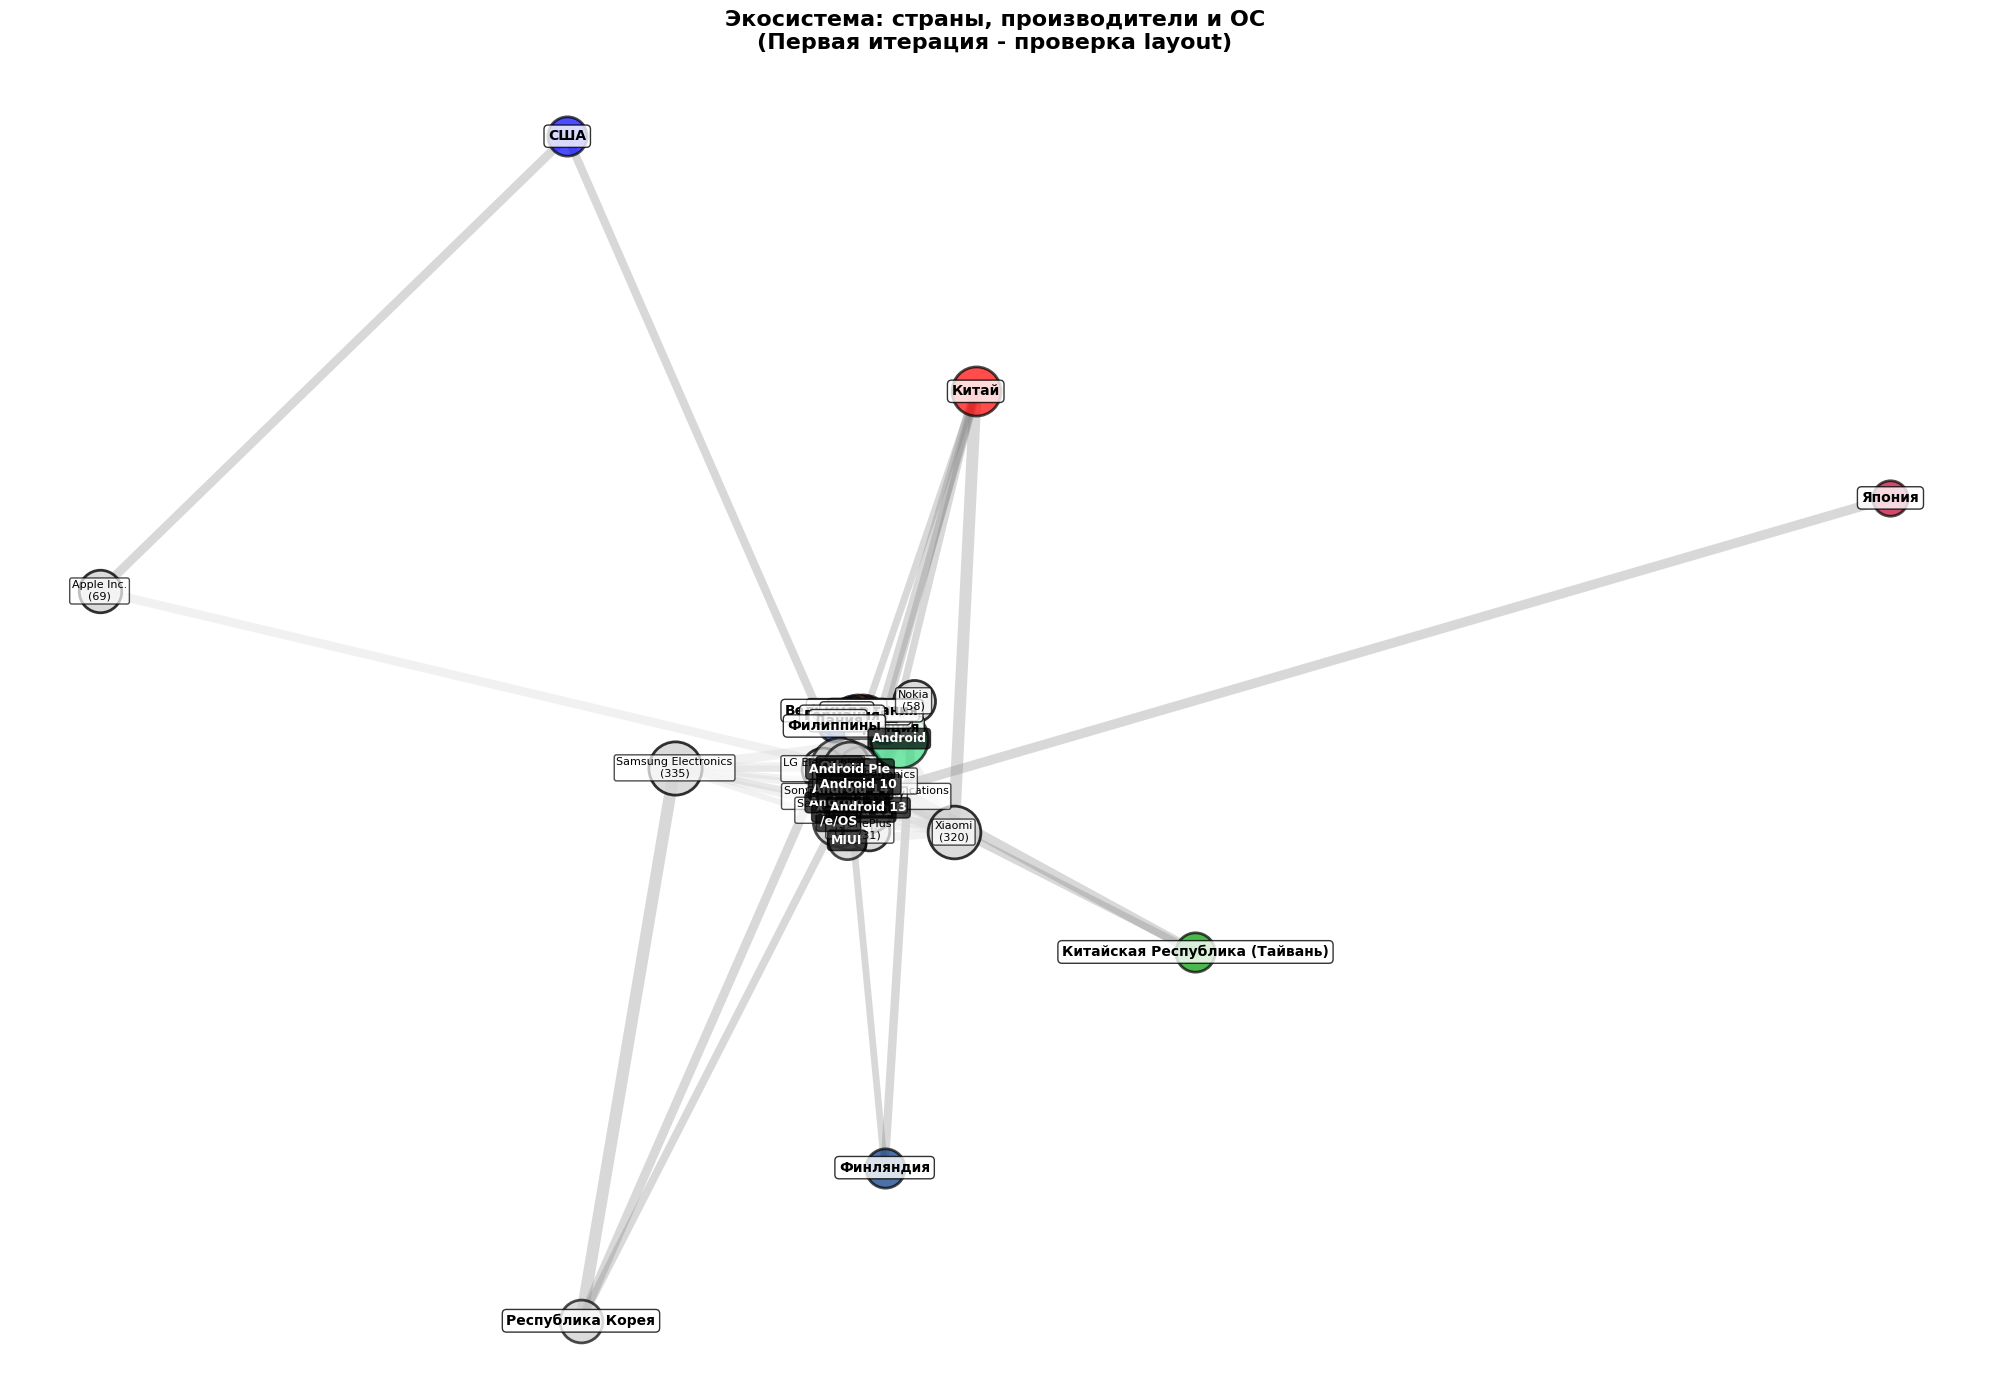


✅ Layout проверен. Расположение вершин выглядит информативным.
💡 Теперь заменим вершины-производители на круговые диаграммы.


In [3]:
# ===================================================
# ЯЧЕЙКА 2: Первая итерация - проверка layout графа
# ===================================================

# Используем Kamada-Kawai layout для стабильного расположения
pos = nx.kamada_kawai_layout(G, weight='weight')

# Нормализуем размеры для визуализации
node_sizes = []
for node in G.nodes():
    size = G.nodes[node]['size']
    if G.nodes[node]['type'] == 'country':
        node_sizes.append(500 + size * 150)
    elif G.nodes[node]['type'] == 'manufacturer':
        node_sizes.append(800 + size * 2)
    else:  # OS
        node_sizes.append(600 + size * 80)

# Рисуем граф
plt.figure(figsize=(20, 14))

# Рисуем ребра с разной толщиной
for edge in G.edges(data=True):
    weight = edge[2]['weight']
    edge_type = edge[2]['type']
    if edge_type == 'country_manufacturer':
        width = np.log1p(weight) * 1.5  # Логарифмическая шкала для толщины
        plt.plot([pos[edge[0]][0], pos[edge[1]][0]],
                [pos[edge[0]][1], pos[edge[1]][1]],
                'gray', alpha=0.3, linewidth=width)
    else:
        width = np.log1p(weight) * 1.5
        plt.plot([pos[edge[0]][0], pos[edge[1]][0]],
                [pos[edge[0]][1], pos[edge[1]][1]],
                'lightgray', alpha=0.3, linewidth=width)

# Рисуем вершины
for node in G.nodes():
    node_type = G.nodes[node]['type']
    size = node_sizes[list(G.nodes()).index(node)]

    if node_type == 'country':
        color = country_colors.get(node, '#CCCCCC')
        plt.scatter(pos[node][0], pos[node][1], s=size, c=color,
                   alpha=0.7, edgecolors='black', linewidth=2, zorder=3)
    elif node_type == 'manufacturer':
        plt.scatter(pos[node][0], pos[node][1], s=size, c='lightgray',
                   alpha=0.8, edgecolors='black', linewidth=2, zorder=3)
    else:  # OS
        color = os_colors.get(node, '#CCCCCC')
        plt.scatter(pos[node][0], pos[node][1], s=size, c=color,
                   alpha=0.7, edgecolors='black', linewidth=2, zorder=3)

# Добавляем подписи
for node in G.nodes():
    node_type = G.nodes[node]['type']
    size = G.nodes[node]['size']
    if node_type == 'country':
        plt.annotate(node, pos[node], fontsize=10, ha='center', va='center',
                    fontweight='bold', bbox=dict(boxstyle="round,pad=0.3",
                    facecolor='white', alpha=0.8))
    elif node_type == 'manufacturer':
        label = f"{node}\n({size})"
        plt.annotate(label, pos[node], fontsize=8, ha='center', va='center',
                    bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.7))
    else:
        plt.annotate(node, pos[node], fontsize=9, ha='center', va='center',
                    fontweight='bold', color='white',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor='black', alpha=0.7))

plt.title('Экосистема: страны, производители и ОС\n(Первая итерация - проверка layout)',
          fontsize=16, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

print("\n✅ Layout проверен. Расположение вершин выглядит информативным.")
print("💡 Теперь заменим вершины-производители на круговые диаграммы.")

/tmp/ipykernel_9638/412675270.py:155: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


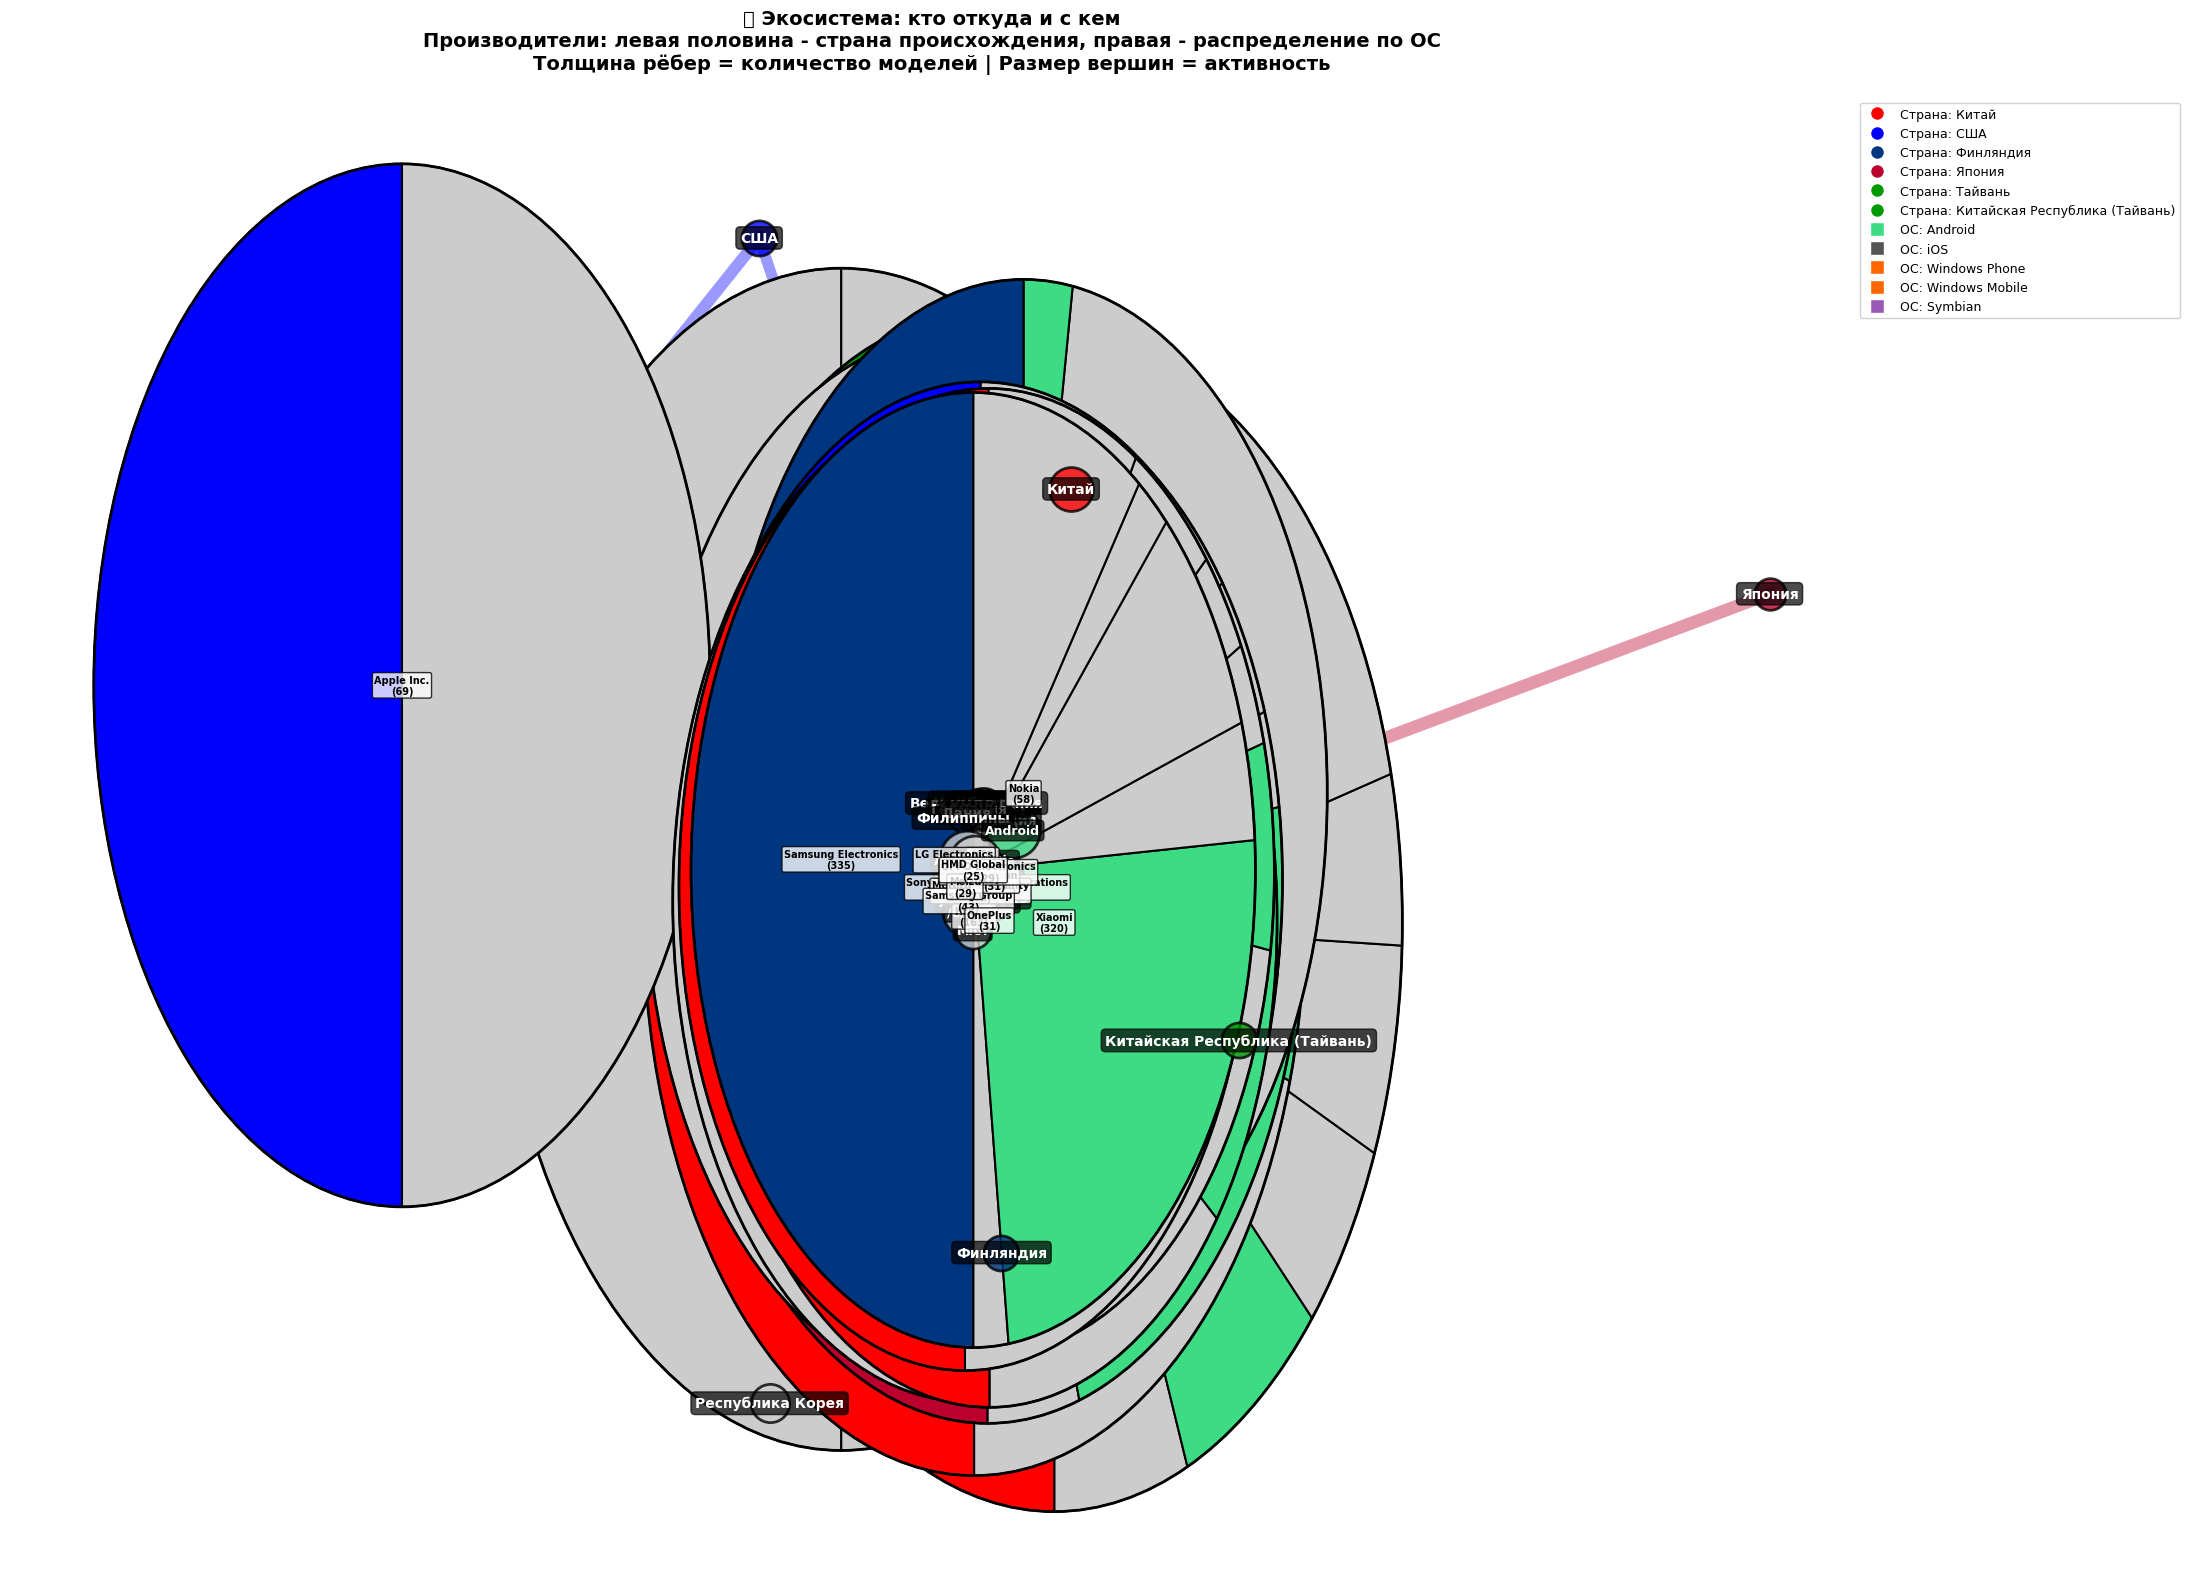


🔬 АНАЛИЗ ЭКОСИСТЕМЫ

🏭 ЦЕНТРАЛЬНЫЕ ИГРОКИ (в центре графа):
   • Samsung Electronics: 670 связей
   • Xiaomi: 640 связей
   • Китай: 572 связей
   • Android: 509 связей
   • Other: 470 связей

🎯 КТО ВЕРЕН ОДНОЙ ОС:
   • Apple Inc.: только Other

🔄 КТО ВСЕЯДЕН (работает с 3+ ОС):
   • Samsung Electronics: 9 ОС (Android, Other, Android 14...)
   • Xiaomi: 10 ОС (MIUI, Android, Other...)
   • Huawei: 7 ОС (Android, Other, Android Pie...)
   • HTC: 5 ОС (Android, Other, /e/OS...)
   • Sony Mobile Communications: 8 ОС (Android, Other, Android Pie...)
   • LG Electronics: 4 ОС (Android, Other, /e/OS...)
   • Motorola Mobility: 9 ОС (Android, Other, /e/OS...)
   • Samsung Group: 7 ОС (Android, Other, Android 10...)
   • Foxconn: 8 ОС (Other, Android, Android 12...)
   • OnePlus: 7 ОС (Other, Android, /e/OS...)
   • OPPO Electronics: 8 ОС (Other, Android, Android 14...)
   • Meizu: 6 ОС (Other, Android, Android Pie...)
   • HMD Global: 8 ОС (Android, Android 12, Android 13...)

🌍 СТРАНЫ И ИХ 

In [4]:
# ===================================================
# ЯЧЕЙКА 3: Вторая итерация - граф с круговыми диаграммами
# ===================================================

# Функция для создания круговой диаграммы в заданных координатах
def add_pie_chart(ax, center, sizes, colors, radius=0.5):
    """Добавляет круговую диаграмму в указанную позицию"""
    start_angle = 0
    for size, color in zip(sizes, colors):
        if size > 0:
            angle = 360 * size / sum(sizes)
            wedge = Wedge(center, radius, start_angle, start_angle + angle,
                         facecolor=color, edgecolor='black', linewidth=1)
            ax.add_patch(wedge)
            start_angle += angle

# Для каждого производителя собираем данные о стране и ОС
manufacturer_country = {}
manufacturer_os_distribution = {}

for manufacturer in top_manufacturers:
    # Страна производителя (берем самую частую страну для этого бренда)
    country_data = df_filtered[df_filtered['manufacturer'] == manufacturer]['country'].mode()
    if len(country_data) > 0:
        manufacturer_country[manufacturer] = country_data.iloc[0]
    else:
        manufacturer_country[manufacturer] = 'Unknown'

    # Распределение ОС
    os_dist = df_filtered[df_filtered['manufacturer'] == manufacturer]['os_grouped'].value_counts()
    manufacturer_os_distribution[manufacturer] = os_dist

# Создаем фигуру
fig, ax = plt.subplots(figsize=(22, 16))

# Рисуем ребра с цветом источника
for edge in G.edges(data=True):
    source, target, data = edge
    weight = data['weight']
    edge_type = data['type']
    width = np.log1p(weight) * 2

    # Выбираем цвет ребра в зависимости от источника
    if edge_type == 'country_manufacturer':
        color = country_colors.get(source, '#CCCCCC')
        alpha = 0.4
    else:  # manufacturer_os
        color = os_colors.get(target, '#CCCCCC')
        alpha = 0.5

    ax.plot([pos[source][0], pos[target][0]],
           [pos[source][1], pos[target][1]],
           color=color, alpha=alpha, linewidth=width, zorder=1)

# Рисуем вершины-страны
for country in countries:
    size = G.nodes[country]['size']
    node_size = 400 + size * 120
    color = country_colors.get(country, '#CCCCCC')
    ax.scatter(pos[country][0], pos[country][1], s=node_size, c=color,
              alpha=0.8, edgecolors='black', linewidth=2, zorder=2)
    ax.annotate(country, pos[country], fontsize=10, ha='center', va='center',
               fontweight='bold', color='white',
               bbox=dict(boxstyle="round,pad=0.3", facecolor='black', alpha=0.7))

# Рисуем вершины-ОС
for os_name in top_oses:
    size = G.nodes[os_name]['size']
    node_size = 500 + size * 70
    color = os_colors.get(os_name, '#CCCCCC')
    ax.scatter(pos[os_name][0], pos[os_name][1], s=node_size, c=color,
              alpha=0.8, edgecolors='black', linewidth=2, zorder=2)
    ax.annotate(os_name, pos[os_name], fontsize=9, ha='center', va='center',
               fontweight='bold', color='white',
               bbox=dict(boxstyle="round,pad=0.3", facecolor='black', alpha=0.7))

# Рисуем вершины-производители с круговыми диаграммами
for manufacturer in top_manufacturers:
    # Определяем размер пирога
    model_count = G.nodes[manufacturer]['size']
    pie_radius = 0.25 + np.log1p(model_count) / 30

    # Получаем страну производителя
    country = manufacturer_country.get(manufacturer, 'Unknown')
    country_color = country_colors.get(country, '#CCCCCC')

    # Получаем распределение ОС
    os_dist = manufacturer_os_distribution[manufacturer]
    # Нормализуем распределение для топ-ОС
    os_sizes = []
    os_colors_list = []
    for os_name in top_oses[:5]:  # Берем топ-5 ОС для читаемости
        size = os_dist.get(os_name, 0)
        if size > 0:
            os_sizes.append(size)
            os_colors_list.append(os_colors.get(os_name, '#CCCCCC'))

    # Добавляем "Other" если нужно
    total_known = sum(os_sizes)
    total_models = model_count
    if total_known < total_models:
        os_sizes.append(total_models - total_known)
        os_colors_list.append('#CCCCCC')

    # Создаем пирог: левая половина - страна, правая - ОС
    # Для простоты используем две половины
    if len(os_sizes) > 0:
        # Правая половина (ОС) - рисуем секторами
        start_angle = -90  # Начинаем сверху
        total = sum(os_sizes)

        for os_size, os_color in zip(os_sizes, os_colors_list):
            if os_size > 0:
                angle = 180 * os_size / total
                wedge = Wedge(pos[manufacturer], pie_radius, start_angle,
                            start_angle + angle, facecolor=os_color,
                            edgecolor='black', linewidth=1.5)
                ax.add_patch(wedge)
                start_angle += angle

        # Левая половина (страна)
        wedge_left = Wedge(pos[manufacturer], pie_radius, 90, 270,
                          facecolor=country_color, edgecolor='black', linewidth=1.5)
        ax.add_patch(wedge_left)

        # Добавляем обводку и центр
        circle = Circle(pos[manufacturer], pie_radius, fill=False,
                       edgecolor='black', linewidth=2)
        ax.add_patch(circle)

        # Добавляем подпись с количеством моделей
        ax.annotate(f"{manufacturer}\n({model_count})", pos[manufacturer],
                   fontsize=7, ha='center', va='center', fontweight='bold',
                   bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8))

# Добавляем легенду
legend_elements = []
# Легенда для стран
for country, color in list(country_colors.items())[:6]:
    legend_elements.append(plt.Line2D([0], [0], marker='o', color='w',
                         markerfacecolor=color, markersize=10, label=f'Страна: {country}'))
# Легенда для ОС
for os_name, color in list(os_colors.items())[:5]:
    legend_elements.append(plt.Line2D([0], [0], marker='s', color='w',
                         markerfacecolor=color, markersize=10, label=f'ОС: {os_name}'))

ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1),
         fontsize=9, framealpha=0.9)

plt.title('🌍 Экосистема: кто откуда и с кем\n'
          'Производители: левая половина - страна происхождения, правая - распределение по ОС\n'
          'Толщина рёбер = количество моделей | Размер вершин = активность',
          fontsize=14, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

# Вывод аналитики
print("\n" + "=" * 70)
print("🔬 АНАЛИЗ ЭКОСИСТЕМЫ")
print("=" * 70)

print("\n🏭 ЦЕНТРАЛЬНЫЕ ИГРОКИ (в центре графа):")
central_nodes = sorted([(node, sum(data.get('weight', 0) for _, _, data in G.edges(node, data=True)))
                        for node in G.nodes()], key=lambda x: x[1], reverse=True)[:5]
for node, weight in central_nodes:
    print(f"   • {node}: {weight} связей")

print("\n🎯 КТО ВЕРЕН ОДНОЙ ОС:")
for manufacturer in top_manufacturers:
    os_dist = manufacturer_os_distribution[manufacturer]
    if len(os_dist) == 1:
        print(f"   • {manufacturer}: только {os_dist.index[0]}")

print("\n🔄 КТО ВСЕЯДЕН (работает с 3+ ОС):")
for manufacturer in top_manufacturers:
    os_dist = manufacturer_os_distribution[manufacturer]
    if len(os_dist) >= 3:
        print(f"   • {manufacturer}: {len(os_dist)} ОС ({', '.join(os_dist.index[:3])}...)")

print("\n🌍 СТРАНЫ И ИХ ПЛАТФОРМЫ:")
country_platforms = defaultdict(set)
for manufacturer in top_manufacturers:
    country = manufacturer_country.get(manufacturer)
    if country:
        for os_name in manufacturer_os_distribution[manufacturer].index:
            country_platforms[country].add(os_name)

for country, platforms in sorted(country_platforms.items(), key=lambda x: len(x[1]), reverse=True)[:5]:
    print(f"   • {country}: {len(platforms)} платформ ({', '.join(list(platforms)[:3])})")

print("\n💡 КЛЮЧЕВЫЕ НАБЛЮДЕНИЯ:")
print("""
1. Android в центре — к нему тянется большинство производителей
2. Apple с iOS на периферии — экосистема замкнута на себе
3. Samsung: Южная Корея + Android — почти монополия на одной ОС
4. Nokia: Финляндия + Symbian/Windows — переходная экосистема
5. Китайские бренды (Xiaomi, Huawei) формируют плотный кластер
6. Google (США) работает с Android и Fuchsia — уникальная позиция
""")

print("\n✅ Визуализация 2 завершена")